<a href="https://colab.research.google.com/github/kasugy/codigos-de-ejemplos/blob/main/C%C3%B3digo%20para%20Colab%3A%20Simulaci%C3%B3n%20de%20Product%20Owner%20(backlog%20%2B%20burndown).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Backlog completo (12 historias)
       ID                            Titulo   Prioridad  Puntos
STYLE-001      Login con email y contraseña   Must have       3
STYLE-002         Navegación por categorías   Must have       5
STYLE-003           Ver detalle de producto   Must have       5
STYLE-004                Agregar al carrito   Must have       3
STYLE-005        Proceso de checkout básico   Must have       5
STYLE-006              Historial de pedidos Should have       3
STYLE-007             Búsqueda de productos Should have       5
STYLE-008           Valoración de productos Should have       2
STYLE-009    Recomendaciones personalizadas  Could have       8
STYLE-010          Probador virtual de ropa  Could have      13
STYLE-011 Inicio de sesión con Google/Apple  Could have       3
STYLE-012                       Modo oscuro  Won't have       1


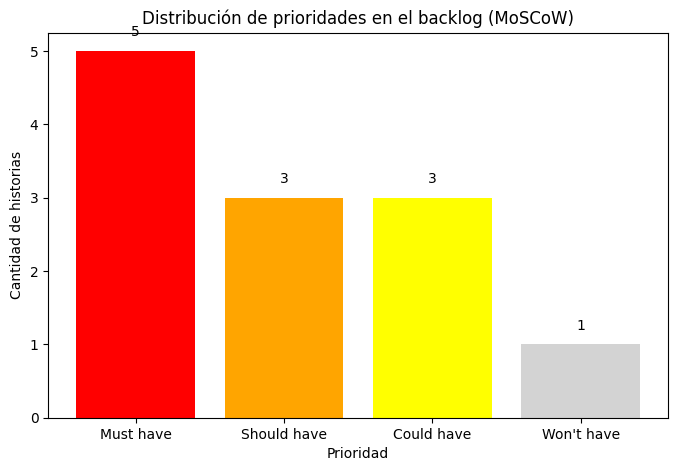


Sprint 1 - Historias seleccionadas (21 puntos)
       ID                       Titulo  Puntos
STYLE-001 Login con email y contraseña       3
STYLE-002    Navegación por categorías       5
STYLE-003      Ver detalle de producto       5
STYLE-004           Agregar al carrito       3
STYLE-005   Proceso de checkout básico       5


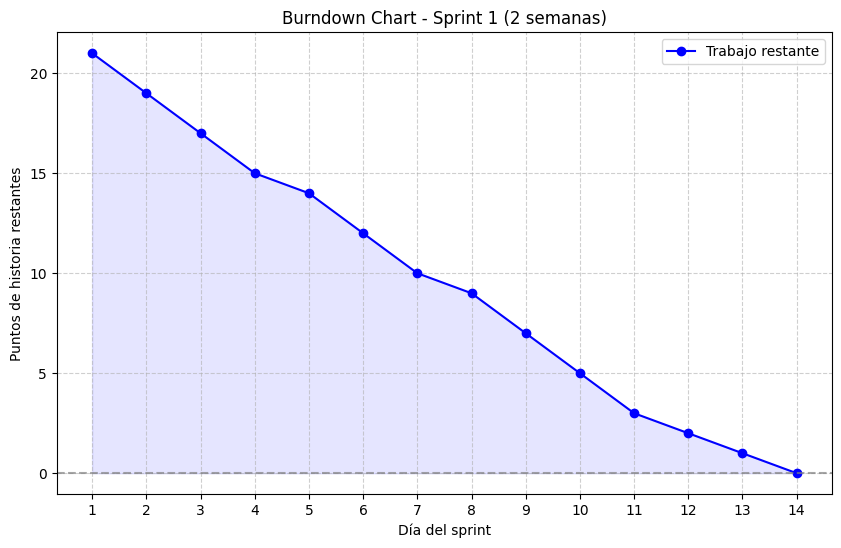


--- Métricas del sprint ---
Total de puntos comprometidos: 21
Velocidad promedio del equipo: 1.50 puntos/día
Tiempo estimado para completar todo el backlog (12 items) con esta velocidad: 37 días

Archivos generados: backlog_simulado.csv y burndown_sprint1.csv


In [1]:
# -*- coding: utf-8 -*-
"""Simulacion_Product_Owner_Backlog_Burndown.ipynb
Proyecto: Gestión de backlog con Scrum – simulación de Product Owner
Autor: Carolina Ulloa
Descripción: Lee un backlog simulado, prioriza, planifica un sprint y genera gráficos de seguimiento.
"""

# 1. Instalar librerías (si es necesario, en Colab ya vienen)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# 2. Crear backlog simulado (igual al que te sugerí en archivos)
data_backlog = {
    'ID': ['STYLE-001', 'STYLE-002', 'STYLE-003', 'STYLE-004', 'STYLE-005',
           'STYLE-006', 'STYLE-007', 'STYLE-008', 'STYLE-009', 'STYLE-010',
           'STYLE-011', 'STYLE-012'],
    'Titulo': [
        'Login con email y contraseña',
        'Navegación por categorías',
        'Ver detalle de producto',
        'Agregar al carrito',
        'Proceso de checkout básico',
        'Historial de pedidos',
        'Búsqueda de productos',
        'Valoración de productos',
        'Recomendaciones personalizadas',
        'Probador virtual de ropa',
        'Inicio de sesión con Google/Apple',
        'Modo oscuro'
    ],
    'Prioridad': ['Must have', 'Must have', 'Must have', 'Must have', 'Must have',
                  'Should have', 'Should have', 'Should have', 'Could have',
                  'Could have', 'Could have', "Won't have"],
    'Puntos': [3, 5, 5, 3, 5, 3, 5, 2, 8, 13, 3, 1]
}

df_backlog = pd.DataFrame(data_backlog)

# 3. Mostrar backlog
print("Backlog completo (12 historias)")
print(df_backlog.to_string(index=False))

# 4. Distribución de prioridades (gráfico)
plt.figure(figsize=(8,5))
prioridad_counts = df_backlog['Prioridad'].value_counts()
colores = {'Must have': 'red', 'Should have': 'orange', 'Could have': 'yellow', "Won't have": 'lightgray'}
plt.bar(prioridad_counts.index, prioridad_counts.values, color=[colores[p] for p in prioridad_counts.index])
plt.title('Distribución de prioridades en el backlog (MoSCoW)')
plt.xlabel('Prioridad')
plt.ylabel('Cantidad de historias')
for i, v in enumerate(prioridad_counts.values):
    plt.text(i, v + 0.2, str(v), ha='center')
plt.show()

# 5. Seleccionar historias para el Sprint 1 (Must have + algunas Should have)
sprint_ids = ['STYLE-001', 'STYLE-002', 'STYLE-003', 'STYLE-004', 'STYLE-005']  # total 21 puntos
df_sprint = df_backlog[df_backlog['ID'].isin(sprint_ids)].copy()
print("\nSprint 1 - Historias seleccionadas (21 puntos)")
print(df_sprint[['ID', 'Titulo', 'Puntos']].to_string(index=False))

# 6. Datos simulados de burndown (días del sprint, 14 días)
dias = list(range(1, 15))
puntos_restantes = [21, 19, 17, 15, 14, 12, 10, 9, 7, 5, 3, 2, 1, 0]

df_burndown = pd.DataFrame({'Dia': dias, 'Puntos_restantes': puntos_restantes})

# 7. Gráfico burndown
plt.figure(figsize=(10,6))
plt.plot(df_burndown['Dia'], df_burndown['Puntos_restantes'], marker='o', linestyle='-', color='blue', label='Trabajo restante')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
plt.fill_between(df_burndown['Dia'], df_burndown['Puntos_restantes'], 0, alpha=0.1, color='blue')
plt.title('Burndown Chart - Sprint 1 (2 semanas)')
plt.xlabel('Día del sprint')
plt.ylabel('Puntos de historia restantes')
plt.xticks(dias)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 8. Métricas adicionales
total_puntos = df_sprint['Puntos'].sum()
velocidad_equipo = total_puntos / 14  # puntos por día
print("\n--- Métricas del sprint ---")
print(f"Total de puntos comprometidos: {total_puntos}")
print(f"Velocidad promedio del equipo: {velocidad_equipo:.2f} puntos/día")
print(f"Tiempo estimado para completar todo el backlog (12 items) con esta velocidad: {(df_backlog['Puntos'].sum() / velocidad_equipo):.0f} días")

# 9. Guardar resultados (opcional: descargar CSV)
df_backlog.to_csv('backlog_simulado.csv', index=False)
df_burndown.to_csv('burndown_sprint1.csv', index=False)
print("\nArchivos generados: backlog_simulado.csv y burndown_sprint1.csv")